# Earthquake-Q — Classical Starter Notebook

**QuantathonV3 · Clemson University**

Welcome. This notebook is your **starting line** — the same one every team gets. It:

1. **Reads** the three data files we supply (`train`, `test`, `judge`) — no downloads, fully offline.
2. **Builds** a forecasting target and a small set of features from the raw data.
3. **Trains** a straightforward gradient-boosted classifier.
4. **Reports** honest accuracy statistics — AUC, information gain, calibration, and more — on data you can see.

Your job for the next 28 hours: **make this better.** Everything here is deliberately plain and
honest. There is a great deal you can improve — the features, the model, the calibration, the way
you handle time. Nothing in this notebook is the ceiling.

> **The one rule that matters:** never let information from *after* a forecast's issue time leak into
> its features. That is the single easiest way to fool yourself. More on this below.


## 0 · Setup

We use only standard, widely available libraries. If `lightgbm` is not installed, the notebook
falls back to scikit-learn's `HistGradientBoostingClassifier` automatically — either works.

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")

from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

# Try LightGBM; fall back to sklearn if unavailable.
try:
    from lightgbm import LGBMClassifier
    HAVE_LGBM = True
except Exception:
    from sklearn.ensemble import HistGradientBoostingClassifier
    HAVE_LGBM = False
print("LightGBM available:", HAVE_LGBM)

LightGBM available: True


## 1 · Read the supplied data

We give you three CSV files, all in the same long format. Put them next to this notebook (or edit
`DATA_DIR`).

| File | Time span | Use it for |
|------|-----------|------------|
| `earthquakeq_train.csv` | 1990–2021 | Fitting your models |
| `earthquakeq_test.csv`  | 2022–2024 | Tuning and model selection |
| `earthquakeq_judge.csv` | 2025–2026 | **Final self-evaluation** — treat as if you can't see it while building |

**Schema (long format).** Each row is one observation from one of five sources:

- `source` — one of `seismic`, `geomagnetic`, `solar`, `tidal_ephemeris`, `gps`
- `time`, `latitude`, `longitude`, `depth_km`, `magnitude` — populated for `seismic`
- `station_id`, `parameter`, `value` — populated for the four non-seismic streams

The **seismic** rows are the earthquake catalog — the signal you are forecasting. The other four
streams are candidate drivers; whether they help is for you to find out.

In [10]:
DATA_DIR = Path(".") / "Data"   # actual dataset folder in this workspace

def load(split):
    candidates = [
        DATA_DIR / f"earthquakeq_{split}.csv",
        DATA_DIR / split / f"earthquakeq_{split}.csv",
    ]
    for path in candidates:
        if path.exists():
            return pd.read_csv(path, parse_dates=["time"])
    raise FileNotFoundError(
        f"Could not find earthquakeq_{split}.csv in {DATA_DIR} or {DATA_DIR / split}"
    )

train_raw = load("train")
test_raw  = load("test")
judge_raw = load("judge")

for name, df in [("train", train_raw), ("test", test_raw), ("judge", judge_raw)]:
    print(f"{name:6s}: {len(df):>7,} rows | sources: {dict(df.source.value_counts())}")

train : 271,207 rows | sources: {'gps': np.int64(189504), 'geomagnetic': np.int64(23376), 'tidal_ephemeris': np.int64(23376), 'solar': np.int64(23354), 'seismic': np.int64(11597)}
test  :  48,328 rows | sources: {'gps': np.int64(39726), 'geomagnetic': np.int64(2192), 'tidal_ephemeris': np.int64(2192), 'solar': np.int64(2191), 'seismic': np.int64(2027)}
judge :  17,979 rows | sources: {'gps': np.int64(14511), 'geomagnetic': np.int64(910), 'tidal_ephemeris': np.int64(910), 'solar': np.int64(908), 'seismic': np.int64(740)}


In [11]:
# The seismic catalog is the signal. Pull it out of each split.
def seismic(df):
    s = df[df.source == "seismic"][["time","latitude","longitude","depth_km","magnitude"]].copy()
    return s.sort_values("time").reset_index(drop=True)

cat_train, cat_test, cat_judge = seismic(train_raw), seismic(test_raw), seismic(judge_raw)
print("seismic events  ->  train:", len(cat_train), " test:", len(cat_test), " judge:", len(cat_judge))
print("train span:", cat_train.time.min().date(), "->", cat_train.time.max().date())
cat_train.head()

seismic events  ->  train: 11597  test: 2027  judge: 740
train span: 1990-01-02 -> 2021-12-31


,time,latitude,longitude,depth_km,magnitude
0,1990-01-02 20:17:24.600,35.093,-82.969,5.7,2.1
1,1990-01-03 04:25:14.900,37.024,-81.817,3.5,2.0
2,1990-01-05 17:40:49.150,36.469,-89.535,2.6,1.5
3,1990-01-06 21:40:10.500,36.490,-89.550,5.8,1.8
4,1990-01-07 16:13:16.700,32.968,-80.218,5.4,2.1


## 2 · Define the forecasting target

We forecast, for a grid cell and a 30-day window, the probability that **at least one earthquake of
magnitude ≥ 2.0 occurs within 100 km of the cell** during the window.

We build training examples as **(cell, issue-date)** pairs: take a grid of cells, evaluate it at many
historical issue dates, and label each example with whether a qualifying event occurred in the
*following* 30 days. This matches how you will be scored — on a grid, at an issue date, looking
forward.

We use a magnitude of completeness `MC = 1.75`: below this the catalog is not reliably complete, so
we forecast events at or above it. (Estimating `MC` well is itself worth thinking about — see the
study deck.)

In [12]:
TARGET_MAG = 2.0     # forecast P(at least one event >= this magnitude)
RADIUS_KM  = 100.0   # ...within this distance of the cell centre
WINDOW_DAYS= 30      # ...during this forward window
GRID_STEP  = 0.5     # cell size in degrees
MC         = 1.75    # magnitude of completeness (events below this are dropped as incomplete)

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1); dl = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

# active grid cells: any cell that ever hosted an event in the training catalog
def active_cells(cat):
    cy = np.floor(cat.latitude / GRID_STEP) * GRID_STEP
    cx = np.floor(cat.longitude / GRID_STEP) * GRID_STEP
    cells = sorted(set(zip(np.round(cy,3), np.round(cx,3))))
    return np.array(cells)

CELLS = active_cells(cat_train)
CC_LAT = CELLS[:,0] + GRID_STEP/2   # cell-centre latitude
CC_LON = CELLS[:,1] + GRID_STEP/2   # cell-centre longitude
print(f"{len(CELLS)} active grid cells across the region")

644 active grid cells across the region


## 3 · Build features from the raw catalog

This is the deliberately-plain part. For each **(cell, issue-date)** example we compute a handful of
simple seismicity features, all using **only events strictly before the issue date** (this is the
anti-leakage rule in code):

- counts of nearby past events over several look-back windows (7 / 30 / 90 / 365 days)
- days since the most recent nearby event (recency)
- the cell-centre latitude and longitude (the spatial prior)

That's it — six-ish numbers. We do **not** touch the geomagnetic, solar, tidal, or GPS streams here.
**Adding them, engineering better features, or bringing in physics is exactly the kind of thing you
might do to improve on this baseline.**

In [13]:
DAY = 86400.0

def build_examples(catalog, issue_dates, cells_lat, cells_lon, label_source_catalog):
    """Create (cell, issue-date) rows with leakage-safe features and a forward-looking label.
       - features use events in `catalog` strictly BEFORE the issue date
       - labels use events in `label_source_catalog` in (issue, issue+WINDOW]
    """
    ev_t = catalog.time.values.astype("datetime64[s]").astype("int64")
    ev_la, ev_lo, ev_m = catalog.latitude.values, catalog.longitude.values, catalog.magnitude.values
    lb_t = label_source_catalog.time.values.astype("datetime64[s]").astype("int64")
    lb_la, lb_lo, lb_m = label_source_catalog.latitude.values, label_source_catalog.longitude.values, label_source_catalog.magnitude.values

    rows, labels = [], []
    for d in issue_dates:
        t0 = np.datetime64(d).astype("datetime64[s]").astype("int64")
        for clat, clon in zip(cells_lat, cells_lon):
            # ---- features: strictly past events within RADIUS ----
            past = ev_t < t0
            dpast = haversine_km(clat, clon, ev_la[past], ev_lo[past]) if past.any() else np.array([])
            tpast = (t0 - ev_t[past]) / DAY if past.any() else np.array([])
            near = dpast <= RADIUS_KM
            c7   = int(np.sum(near & (tpast <=   7)))
            c30  = int(np.sum(near & (tpast <=  30)))
            c90  = int(np.sum(near & (tpast <=  90)))
            c365 = int(np.sum(near & (tpast <= 365)))
            recency = float(tpast[near].min()) if near.any() else 999.0
            rows.append([clat, clon, c7, c30, c90, c365, np.log1p(recency)])
            # ---- label: any qualifying event in the forward window ----
            fut = (lb_t > t0) & (lb_t <= t0 + WINDOW_DAYS*DAY)
            if fut.any():
                dfut = haversine_km(clat, clon, lb_la[fut], lb_lo[fut])
                hit = np.any((dfut <= RADIUS_KM) & (lb_m[fut] >= TARGET_MAG))
            else:
                hit = False
            labels.append(int(hit))
    X = np.array(rows, dtype=float)
    y = np.array(labels, dtype=int)
    return X, y

FEATURE_NAMES = ["cell_lat","cell_lon","count_7d","count_30d","count_90d","count_365d","log_recency"]

In [14]:
# Issue dates: monthly. Training issues span the training catalog; test/judge use their own spans.
def monthly(start, end):
    return pd.date_range(start, end, freq="MS")

# Apply completeness cut for FEATURES and LABELS consistently
def complete(cat): return cat[cat.magnitude >= MC].reset_index(drop=True)
ct, ce, cj = complete(cat_train), complete(cat_test), complete(cat_judge)

# For each split, features are built from all events up to each issue date.
# We concatenate the relevant history so test/judge can 'see' past events for their features.
hist_for_test  = pd.concat([ct, ce]).sort_values("time").reset_index(drop=True)
hist_for_judge = pd.concat([ct, ce, cj]).sort_values("time").reset_index(drop=True)

print("Building TRAIN examples (this is the slow step; ~1-2 min)...")
Xtr, ytr = build_examples(ct, monthly("2001-01-01","2021-11-01"), CC_LAT, CC_LON, ct)
print("  train:", Xtr.shape, "positives:", ytr.mean().round(4))

print("Building TEST examples...")
Xte, yte = build_examples(hist_for_test, monthly("2022-01-01","2024-11-01"), CC_LAT, CC_LON, ce)
print("  test :", Xte.shape, "positives:", yte.mean().round(4))

print("Building JUDGE examples...")
Xju, yju = build_examples(hist_for_judge, monthly("2025-01-01","2026-02-01"), CC_LAT, CC_LON, cj)
print("  judge:", Xju.shape, "positives:", yju.mean().round(4))

Building TRAIN examples (this is the slow step; ~1-2 min)...
  train: (161644, 7) positives: 0.1365
Building TEST examples...
  test : (22540, 7) positives: 0.169
Building JUDGE examples...
  judge: (9016, 7) positives: 0.1765


## 4 · Train a plain classical baseline

One gradient-boosted tree, sensible defaults, no tuning. We fit on train, and (optionally) calibrate
the probabilities on the test split using isotonic regression so the numbers we report are honest.

**Ideas to beat this:** tune the model, add the other data streams, engineer richer features
(b-values, ETAS intensity, acceleration), handle time more carefully, ensemble, or bring in a physics
baseline. All fair game.

In [15]:
def make_model():
    if HAVE_LGBM:
        return LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31,
                              subsample=0.8, colsample_bytree=0.8, random_state=SEED, verbose=-1)
    else:
        return HistGradientBoostingClassifier(max_iter=400, learning_rate=0.05, max_depth=4,
                                               l2_regularization=1.0, random_state=SEED)

model = make_model()
model.fit(Xtr, ytr)

# raw probabilities
p_test_raw  = model.predict_proba(Xte)[:,1]
p_judge_raw = model.predict_proba(Xju)[:,1]

# calibrate on TEST (isotonic), apply to JUDGE — honest, leakage-safe calibration
iso = IsotonicRegression(out_of_bounds="clip").fit(p_test_raw, yte)
p_test  = np.clip(iso.predict(p_test_raw),  1e-4, 1-1e-4)
p_judge = np.clip(iso.predict(p_judge_raw), 1e-4, 1-1e-4)
print("Trained. Calibrated probabilities ready.")

Trained. Calibrated probabilities ready.


## 5 · Honest accuracy statistics

We report the full picture, not just one number. Read them together — a high AUC with poor
calibration is a *bad* forecast.

- **AUC** — ranking skill (can the model order risky cells above safe ones?)
- **PR-AUC** — precision–recall area, the honest view for a rare target
- **Information gain (bits)** — how much you beat the base rate, per prediction. **This is the metric
  that matters most.**
- **Brier score** & **calibration error (ECE)** — are your stated probabilities *true*?

In [17]:
def information_gain_bits(y, p, base_rate):
    p = np.clip(p, 1e-4, 1-1e-4)
    ll_model = -np.mean(y*np.log(p) + (1-y)*np.log(1-p))
    b = np.clip(base_rate, 1e-4, 1-1e-4)
    ll_clim  = -np.mean(y*np.log(b) + (1-y)*np.log(1-b))
    return (ll_clim - ll_model) / np.log(2)

def ece(y, p, bins=10):
    edges = np.linspace(0,1,bins+1); e = 0.0
    for i in range(bins):
        m = (p>=edges[i]) & (p<edges[i+1])
        if m.sum()>0:
            e += (m.sum()/len(p)) * abs(y[m].mean() - p[m].mean())
    return e

def scorecard(name, y, p, base_rate):
    return {
        "split": name,
        "AUC":    roc_auc_score(y, p),
        "PR_AUC": average_precision_score(y, p),
        "IG_bits":information_gain_bits(y, p, base_rate),
        "Brier":  brier_score_loss(y, p),
        "ECE":    ece(y, p),
        "base_rate": base_rate, "positives": int(y.sum()), "n": len(y),
    }

base = ytr.mean()   # climatology = training base rate
rows = [scorecard("test", yte, p_test, base), scorecard("judge", yju, p_judge, base)]
score_df = pd.DataFrame(rows).set_index("split")
pd.options.display.float_format = lambda v: f"{v:.4f}"
print("=== Classical baseline — accuracy statistics ===")
score_df[["AUC","PR_AUC","IG_bits","Brier","ECE","base_rate","positives","n"]]

=== Classical baseline — accuracy statistics ===


,AUC,PR_AUC,IG_bits,Brier,ECE,base_rate,positives,n
split,,,,,,,,
test,0.8035,0.5340,0.1562,0.1070,0.0000,0.1365,3810,22540
judge,0.7931,0.5263,0.1451,0.1120,0.0153,0.1365,1591,9016


## 6 · The curves

ROC, precision–recall, and a reliability (calibration) diagram on the held-out **judge** split.
These are your visual baseline — beat them.

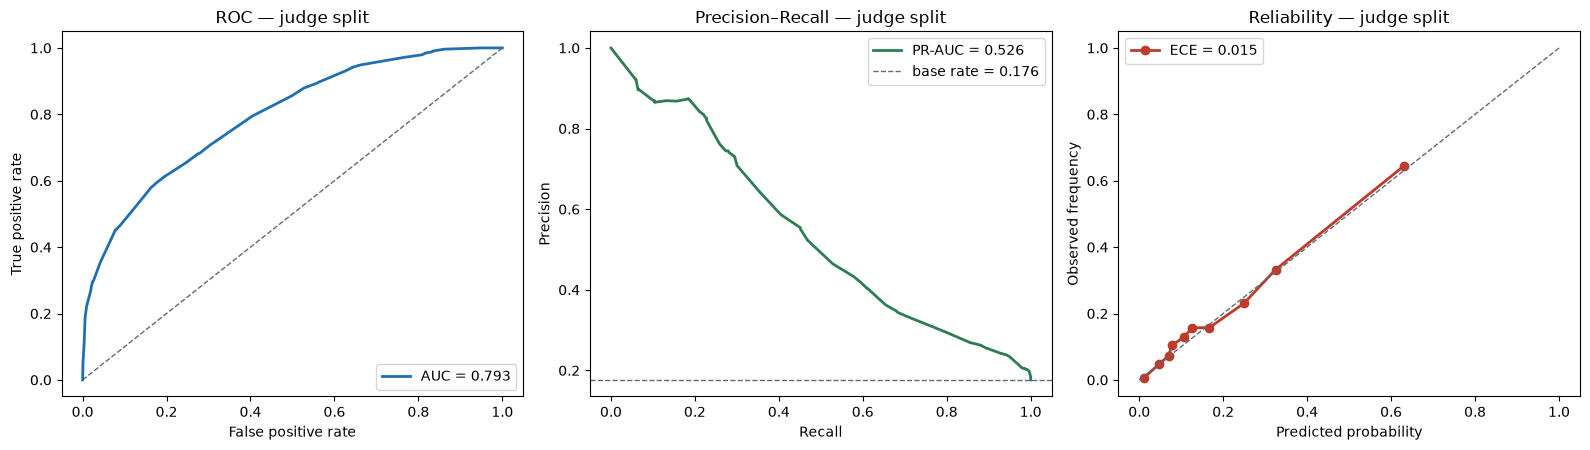

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(16,4.6))

# ROC
fpr, tpr, _ = roc_curve(yju, p_judge)
ax[0].plot(fpr, tpr, color="#1F6FB2", lw=2, label=f"AUC = {roc_auc_score(yju,p_judge):.3f}")
ax[0].plot([0,1],[0,1],"--",color="#5B6B7A",lw=1)
ax[0].set_xlabel("False positive rate"); ax[0].set_ylabel("True positive rate")
ax[0].set_title("ROC — judge split"); ax[0].legend(loc="lower right")

# PR
prec, rec, _ = precision_recall_curve(yju, p_judge)
ax[1].plot(rec, prec, color="#2E7D53", lw=2, label=f"PR-AUC = {average_precision_score(yju,p_judge):.3f}")
ax[1].axhline(yju.mean(), ls="--", color="#5B6B7A", lw=1, label=f"base rate = {yju.mean():.3f}")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
ax[1].set_title("Precision–Recall — judge split"); ax[1].legend(loc="upper right")

# Reliability
frac_pos, mean_pred = calibration_curve(yju, p_judge, n_bins=10, strategy="quantile")
ax[2].plot(mean_pred, frac_pos, "o-", color="#C0392B", lw=2, label=f"ECE = {ece(yju,p_judge):.3f}")
ax[2].plot([0,1],[0,1],"--",color="#5B6B7A",lw=1)
ax[2].set_xlabel("Predicted probability"); ax[2].set_ylabel("Observed frequency")
ax[2].set_title("Reliability — judge split"); ax[2].legend(loc="upper left")

plt.tight_layout(); plt.show()

## 7 · Your turn

You now have a complete, honest, working forecast. It is **plain on purpose.** Some directions teams
often explore (no promises — you decide what's worth it):

- **Richer seismicity features** — b-values, event-rate acceleration, moment release, multi-radius counts.
- **The other four data streams** — geomagnetic, solar, tidal, GPS. Do they add anything? Prove it, don't assume it.
- **A physics baseline** — the ETAS aftershock model is a classic; feeding its forecast in as a feature is a strong move.
- **Better calibration and model selection** — how you split time and calibrate can matter more than the model.
- **Quantum approaches** — encodings, kernels, variational classifiers, if your track calls for it.

**Two things worth remembering:**
1. Report your gains *with* calibration, and always check your held-out (judge) number against your
   own test number — if judge is far worse, you probably leaked.
2. If your fancy pipeline doesn't clearly beat this simple one, that's a real and interesting result.
   Say so, honestly, with the numbers to back it up.

Good luck. Build something you can defend.